In [1]:
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from torch.utils.data import Subset
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import sys
sys.path.insert(0, '/pbabkin/main/mipt/nas-for-moe/code/data')
sys.path.insert(0, '/pbabkin/main/mipt/nas-for-moe/code')
sys.path.insert(0, '/pbabkin/main/mipt/nas-for-moe/code/toy_experiment')
import toy_searchspace
import nas_moe.vae
import nas_moe.dataset
import nas_moe.surrogate
import nas_moe.single_arch
import nas_moe.graph
import nas_moe.utils
import os
from torch.utils.data import DataLoader
from torch_geometric.data import Batch
from pathlib import Path
import torch.nn as nn
from torch.utils.data import DataLoader
from torch_geometric.data import Batch
from tqdm import tqdm
from nni.nas.hub.pytorch import DARTS as DartsSpace
from torch_geometric.utils import dense_to_sparse
import random
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import numpy as np


SEED = 322
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.10/dist-packages/nni/nas/nn/pytorch/layers.py:94: RuntimeWarning: <class 'torch.nn.parameter.Buffer'> is found to be not a nn.Module, which is unexpected. It means your PyTorch version might not be supported.
  warnings.warn(f'{obj} is found to be not a nn.Module, which is unexpected. '


# Prepare data

In [2]:
X_combined = np.load('/pbabkin/main/mipt/nas-for-moe/code/toy_experiment/data/data_X.npy')
y_combined = np.load('/pbabkin/main/mipt/nas-for-moe/code/toy_experiment/data/data_y.npy')

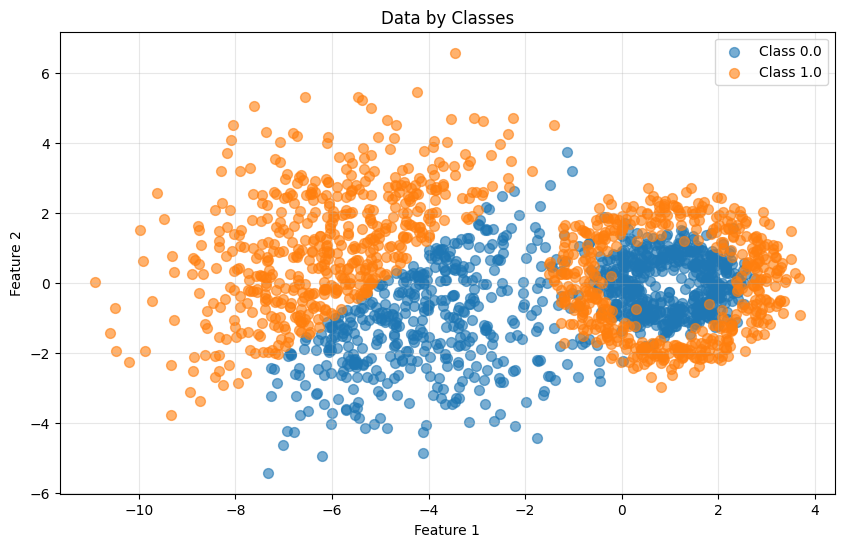

In [3]:
plt.figure(figsize=(10, 6))

for class_label in np.unique(y_combined):
    mask = y_combined == class_label
    plt.scatter(X_combined[mask, 0], X_combined[mask, 1], 
                label=f'Class {class_label}', alpha=0.6, s=50)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Data by Classes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
n_clusters = 2

kmeans = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_combined)

In [5]:
X0 = X_combined[clusters == 0]
y0 = y_combined[clusters == 0]

X1 = X_combined[clusters == 1]
y1 = y_combined[clusters == 1]

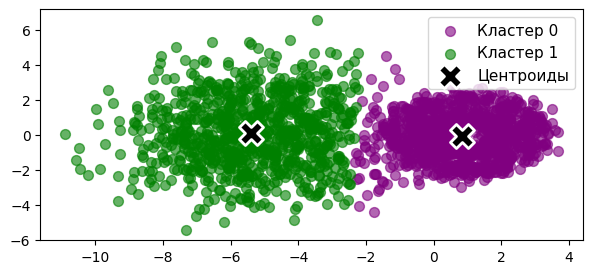

In [6]:
fig, ax = plt.subplots(figsize=(7, 3))

colors_kmeans = ['purple', 'green']
for i in range(n_clusters):
    ax.scatter(X_combined[clusters == i, 0], 
               X_combined[clusters == i, 1], 
               label=f'Кластер {i}', alpha=0.6, s=50, color=colors_kmeans[i])

# Отображаем центроиды
ax.scatter(kmeans.cluster_centers_[:, 0], 
           kmeans.cluster_centers_[:, 1], 
           label='Центроиды', marker='X', s=300, color='black', edgecolors='white', linewidth=2)

ax.legend(fontsize=11)

plt.show()

# Train

In [7]:
def train_cell(cell, X, y, epochs=100, lr=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED
    )
    
    X_train = torch.FloatTensor(X_train)
    y_train = torch.LongTensor(y_train)
    X_test = torch.FloatTensor(X_test)
    y_test = torch.LongTensor(y_test)
    
    optimizer = torch.optim.SGD(cell.parameters(), lr=lr, momentum=0.9, nesterov=True)
    criterion = nn.CrossEntropyLoss()

    batch_size=32
    n_batches = len(X_train) // batch_size
    
    for epoch in range(epochs):
        # Shuffle данных
        indices = torch.randperm(len(X_train))
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]
        
        epoch_loss = 0
        for i in range(n_batches):
            start_idx = i * batch_size
            end_idx = start_idx + batch_size
            
            batch_X = X_train_shuffled[start_idx:end_idx]
            batch_y = y_train_shuffled[start_idx:end_idx]
            
            optimizer.zero_grad()
            outputs = cell(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(cell.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
        
        if (epoch + 1) % 20 == 0:
            with torch.no_grad():
                test_outputs = cell(X_test)
                test_preds = torch.argmax(test_outputs, dim=1)
                test_acc = (test_preds == y_test).float().mean()
            avg_loss = epoch_loss / n_batches
            print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Test Acc={test_acc:.4f}")
    
    return test_acc.item()

In [8]:
ss = toy_searchspace.ToySearchSpace(input_dim=2, num_nodes_per_cell=3)

# Обучение по кластерам

In [9]:
random_config = ss.create_random_config()
cell = ss.create_cell_from_config(random_config)

In [10]:
random_config

{'op_0': np.str_('skip_connect'),
 'input_0': [-1],
 'op_1': np.str_('linear'),
 'input_1': [0],
 'op_2': np.str_('skip_connect'),
 'input_2': [1]}

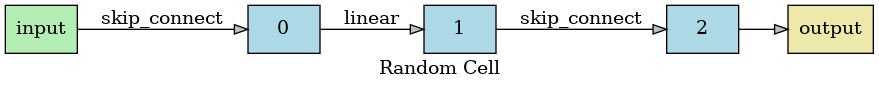

In [11]:
toy_searchspace.plot_single_cell(random_config)

In [12]:
train_cell(cell, X_combined, y_combined)

Epoch 20: Loss=0.6808, Test Acc=0.5000
Epoch 40: Loss=0.6772, Test Acc=0.6475
Epoch 60: Loss=0.6602, Test Acc=0.6425
Epoch 80: Loss=0.6595, Test Acc=0.6425
Epoch 100: Loss=0.6833, Test Acc=0.6325


0.6324999928474426

# Cluster 0

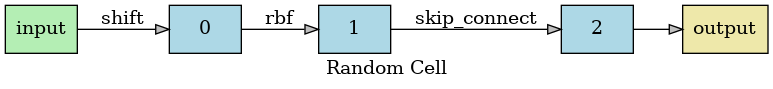

In [59]:
config0 = {
    'op_0': np.str_('shift'),
    'input_0': [-1],
    'op_1': np.str_('rbf'),
    'input_1': [0],
    'op_2': np.str_('skip_connect'),
    'input_2': [1]
}
toy_searchspace.plot_single_cell(config0)
cell0 = ss.create_cell_from_config(config0)

In [54]:
train_cell(cell0, X0, y0)

Epoch 20: Loss=0.3601, Test Acc=0.8802
Epoch 40: Loss=0.3518, Test Acc=0.8802
Epoch 60: Loss=0.3604, Test Acc=0.8756
Epoch 80: Loss=0.3671, Test Acc=0.8802
Epoch 100: Loss=0.3554, Test Acc=0.8710


0.8709677457809448

# Cluster 1

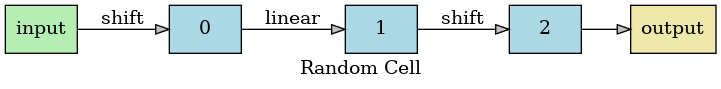

In [23]:
config1 = {
    'op_0': np.str_('shift'),
    'input_0': [-1],
    'op_1': np.str_('linear'),
    'input_1': [0],
    'op_2': np.str_('shift'),
    'input_2': [1]
}
toy_searchspace.plot_single_cell(config1)
cell1 = ss.create_cell_from_config(config1)

In [24]:
train_cell(cell1, X1, y1)

Epoch 20: Loss=0.0383, Test Acc=0.9946
Epoch 40: Loss=0.0317, Test Acc=0.9565
Epoch 60: Loss=0.0480, Test Acc=0.9837
Epoch 80: Loss=0.0408, Test Acc=0.9728
Epoch 100: Loss=0.0459, Test Acc=0.9565


0.95652174949646

In [60]:
train_cell(cell0, X1, y1)

Epoch 20: Loss=0.6841, Test Acc=0.5815
Epoch 40: Loss=0.4769, Test Acc=0.7228
Epoch 60: Loss=0.4588, Test Acc=0.7935
Epoch 80: Loss=0.4376, Test Acc=0.7772
Epoch 100: Loss=0.4362, Test Acc=0.7717


0.77173912525177